# eval — did the labeled crops improve pose on crops?

Compares the pose model trained **without** the hen crops (`v3`) against the one trained **with** them (`v4`), evaluated on the held-out **crop validation set** (the 12 labeled crops that neither model trained on). This is the apples-to-apples test of whether labeling the crops improved crop-pose quality.

Metrics per model: detection **recall**, **PCK@0.05 / PCK@0.10** (fraction of visible ground-truth keypoints within 5% / 10% of the box diagonal), and mean keypoint confidence — reported overall and **split by camera** (cam0 top vs cam1 side), since the top-camera crops are often motion-blurred.

> The crop labels were exported from Roboflow in a different keypoint order than the model schema, so the ground truth is remapped to the base order before scoring (`PC_FROM_BASE`).

Run top to bottom.

In [1]:
import os, warnings, json
warnings.filterwarnings("ignore")
from pathlib import Path
import cv2
import numpy as np
from ultralytics import YOLO

# Resolve repo root (contains pen_config.json) so relative paths work.
root = Path.cwd()
for _ in range(6):
    if (root / "pen_config.json").exists():
        break
    root = root.parent
os.chdir(root)

# Models to compare. Both held the crop val set out of training.
MODELS = {
    "v3 (no crops)":   "models/hen_pose_yolo12s_aug_v3.pt",
    "v4 (with crops)": "runs/pose/runs/pose/hen_pose_yolo12s_aug_v4/weights/best.pt",
}

# Held-out, labeled crop validation set (Roboflow keypoint order).
CROP_VAL_IMG = Path("dataset/pose/pose-crops/images/val")
CROP_VAL_LBL = Path("dataset/pose/pose-crops/labels/val")

# Remap Roboflow crop-export keypoint order -> base model order:
# base_kpts[i] = roboflow_kpts[PC_FROM_BASE[i]]
PC_FROM_BASE = [4, 5, 6, 8, 7, 9, 2, 3, 1, 0]

N_KPTS = 10
CONF = 0.25
PCK_THRESHOLDS = (0.05, 0.10)
SKELETON = [(9, 8), (8, 6), (6, 7), (7, 0), (0, 1), (7, 2), (7, 3), (2, 4), (3, 5)]

imgs = sorted(CROP_VAL_IMG.glob("*.jpg")) + sorted(CROP_VAL_IMG.glob("*.png"))
print("models:", list(MODELS))
print("crop val images:", len(imgs))

models: ['v3 (no crops)', 'v4 (with crops)']
crop val images: 12


In [2]:
# Helper functions: matching, GT loading (with keypoint remap), scoring.
def iou(a, b):
    ix1, iy1 = max(a[0], b[0]), max(a[1], b[1])
    ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])
    iw, ih = max(0.0, ix2 - ix1), max(0.0, iy2 - iy1)
    inter = iw * ih
    if inter <= 0:
        return 0.0
    ua = (a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter
    return inter / ua if ua > 0 else 0.0

def load_gt(label_path, w, h):
    """Load GT boxes/keypoints, remapping keypoints from Roboflow order to base order."""
    gts = []
    if not label_path.exists():
        return gts
    for line in label_path.read_text().splitlines():
        p = line.split()
        if len(p) < 5 + N_KPTS * 3:
            continue
        cx, cy, bw, bh = [float(v) for v in p[1:5]]
        box = [(cx-bw/2)*w, (cy-bh/2)*h, (cx+bw/2)*w, (cy+bh/2)*h]
        rb = [p[5+3*j: 5+3*j+3] for j in range(N_KPTS)]   # roboflow-order triples
        kp = np.zeros((N_KPTS, 3), np.float32)
        for i in range(N_KPTS):
            x, y, v = rb[PC_FROM_BASE[i]]
            kp[i] = [float(x)*w, float(y)*h, float(v)]
        gts.append({"box": box, "kpts": kp})
    return gts

def instances(r):
    if r.keypoints is None or r.boxes is None or len(r.boxes) == 0:
        return []
    kxy = r.keypoints.data.cpu().numpy()
    boxes = r.boxes.xyxy.cpu().numpy()
    sc = r.boxes.conf.cpu().numpy()
    return [{"box": [float(v) for v in boxes[i]], "kpts": kxy[i].astype(np.float32), "score": float(sc[i])}
            for i in range(len(boxes))]

def match(preds, gts):
    pairs, used = [], set()
    for pi in sorted(range(len(preds)), key=lambda i: -preds[i]["score"]):
        best, gj = 0.0, -1
        for gi, gt in enumerate(gts):
            if gi in used:
                continue
            v = iou(preds[pi]["box"], gt["box"])
            if v > best:
                best, gj = v, gi
        if gj >= 0 and best >= 0.5:
            used.add(gj); pairs.append((preds[pi], gts[gj]))
    return pairs

def new_acc():
    a = {"gt": 0, "matched": 0, "vis": 0, "conf": 0.0}
    for t in PCK_THRESHOLDS:
        a["pck%s" % t] = 0
    return a

def accumulate(preds, gts, acc):
    acc["gt"] += len(gts)
    for pred, gt in match(preds, gts):
        acc["matched"] += 1
        diag = float(np.hypot(gt["box"][2]-gt["box"][0], gt["box"][3]-gt["box"][1]))
        if diag <= 0:
            continue
        for j in range(N_KPTS):
            if gt["kpts"][j, 2] <= 0:
                continue
            acc["vis"] += 1
            d = float(np.hypot(pred["kpts"][j, 0]-gt["kpts"][j, 0], pred["kpts"][j, 1]-gt["kpts"][j, 1]))
            acc["conf"] += float(pred["kpts"][j, 2])
            for t in PCK_THRESHOLDS:
                if d <= t * diag:
                    acc["pck%s" % t] += 1

def summary(acc):
    vis = max(acc["vis"], 1)
    out = {"recall": round(acc["matched"] / max(acc["gt"], 1), 3),
           "mean_kpt_conf": round(acc["conf"] / vis, 3)}
    for t in PCK_THRESHOLDS:
        out["PCK@%s" % t] = round(acc["pck%s" % t] / vis, 3)
    return out

def cam_of(name):
    return "cam0" if name.startswith("cam0") else ("cam1" if name.startswith("cam1") else "other")

print("helpers ready")

helpers ready


In [3]:
# Run each model over the crop val set; accumulate overall and per camera.
rows = {}
preds_cache = {}    # (model, image) -> (img, gts, preds) for the visualization cell
for mname, mpath in MODELS.items():
    model = YOLO(mpath)
    acc = {"all": new_acc(), "cam0": new_acc(), "cam1": new_acc()}
    for ip in imgs:
        img = cv2.imread(str(ip))
        if img is None:
            continue
        h, w = img.shape[:2]
        gts = load_gt(CROP_VAL_LBL / (ip.stem + ".txt"), w, h)
        preds = instances(model.predict(img, conf=CONF, verbose=False)[0])
        preds_cache[(mname, ip.name)] = (img, gts, preds)
        accumulate(preds, gts, acc["all"])
        cam = cam_of(ip.name)
        if cam in acc:
            accumulate(preds, gts, acc[cam])
    rows[mname] = acc
    print(f"{mname}: done")

v3 (no crops): done
v4 (with crops): done


In [4]:
# Results: overall and per-camera comparison.
import pandas as pd

overall = pd.DataFrame({m: summary(rows[m]["all"]) for m in MODELS})
print("OVERALL (held-out crop val set):")
display(overall)

for cam in ("cam0", "cam1"):
    n = sum(1 for ip in imgs if cam_of(ip.name) == cam)
    print(f"\n{cam}  ({n} crops):")
    display(pd.DataFrame({m: summary(rows[m][cam]) for m in MODELS}))

OVERALL (held-out crop val set):


,v3 (no crops),v4 (with crops)
recall,0.750,0.900
mean_kpt_conf,0.751,0.728
PCK@0.05,0.163,0.254
PCK@0.1,0.380,0.623



cam0  (0 crops):


,v3 (no crops),v4 (with crops)
recall,0.0,0.0
mean_kpt_conf,0.0,0.0
PCK@0.05,0.0,0.0
PCK@0.1,0.0,0.0



cam1  (12 crops):


,v3 (no crops),v4 (with crops)
recall,0.750,0.900
mean_kpt_conf,0.751,0.728
PCK@0.05,0.163,0.254
PCK@0.1,0.380,0.623


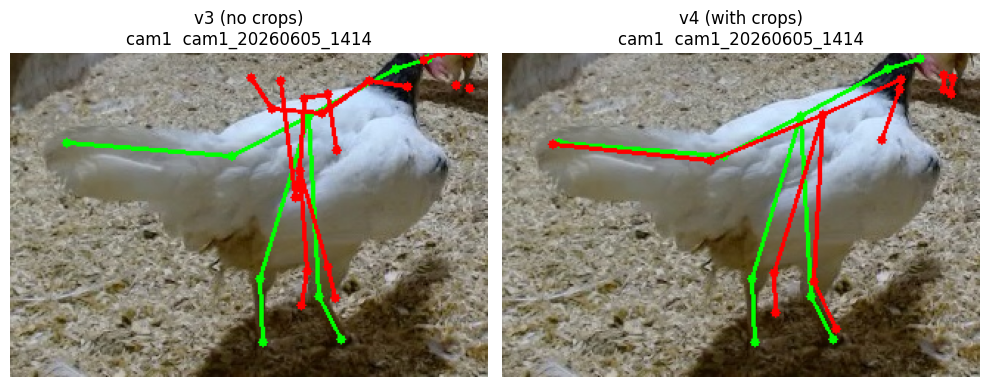

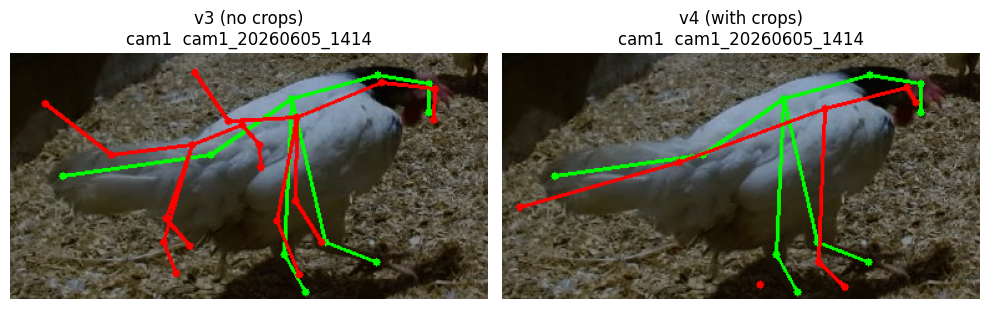

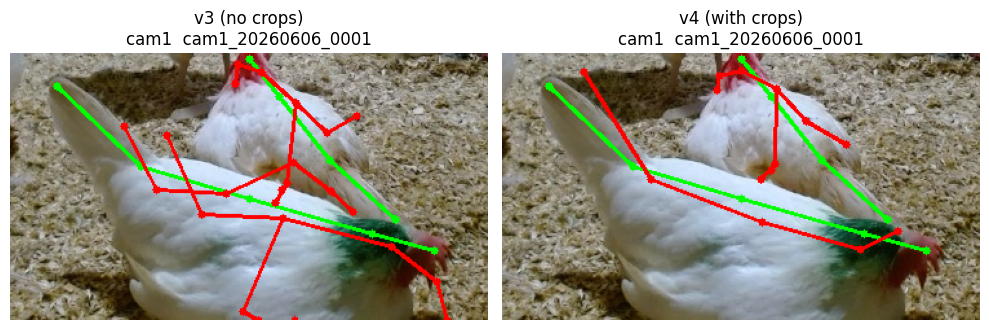

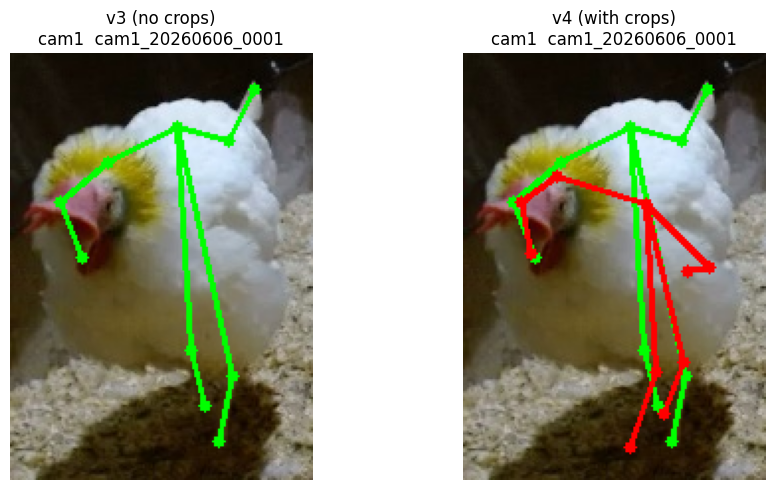

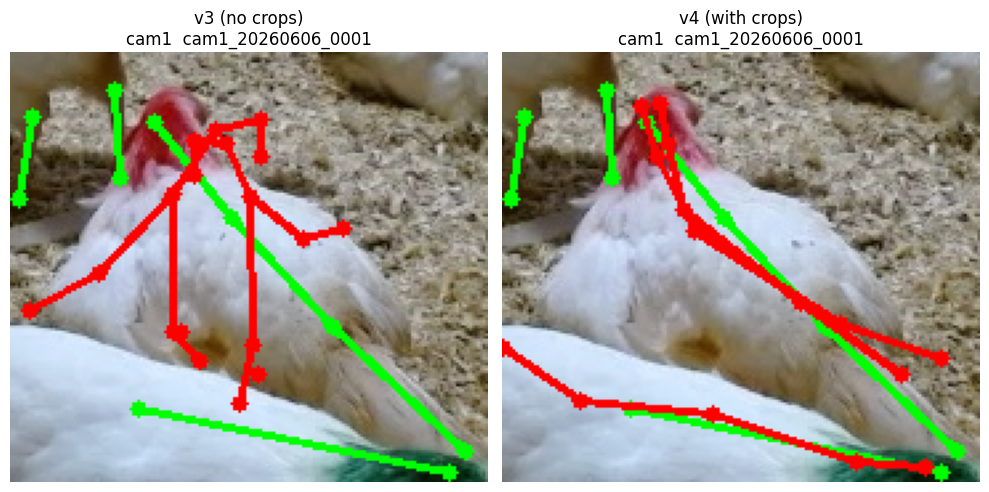

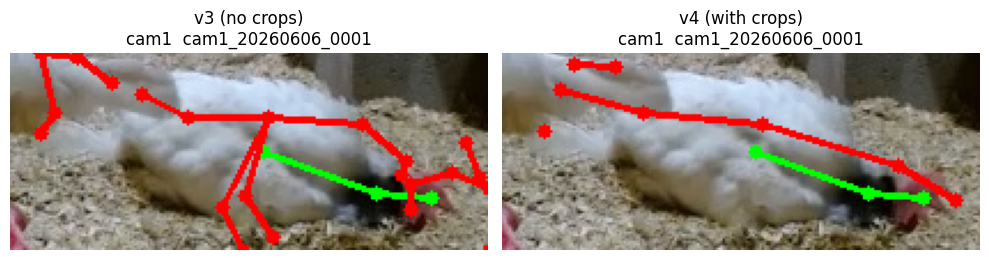

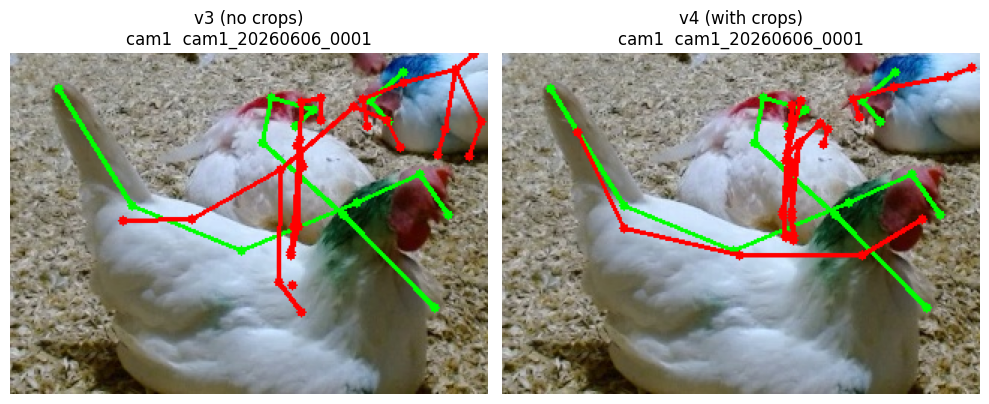

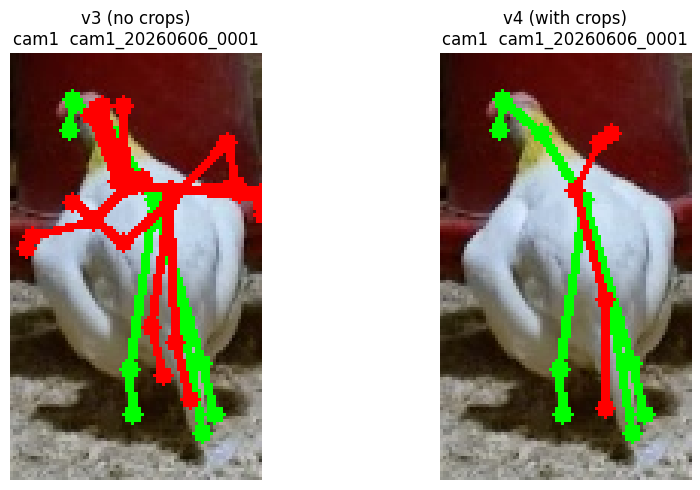

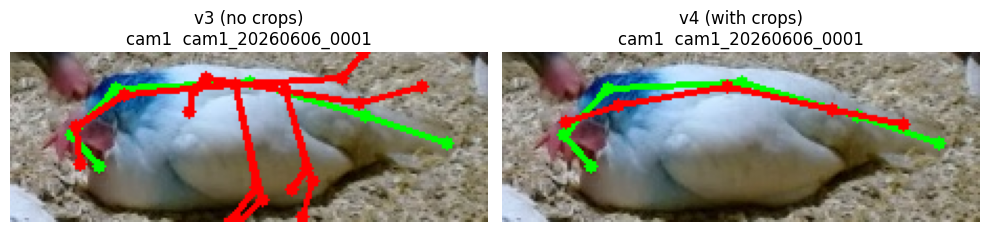

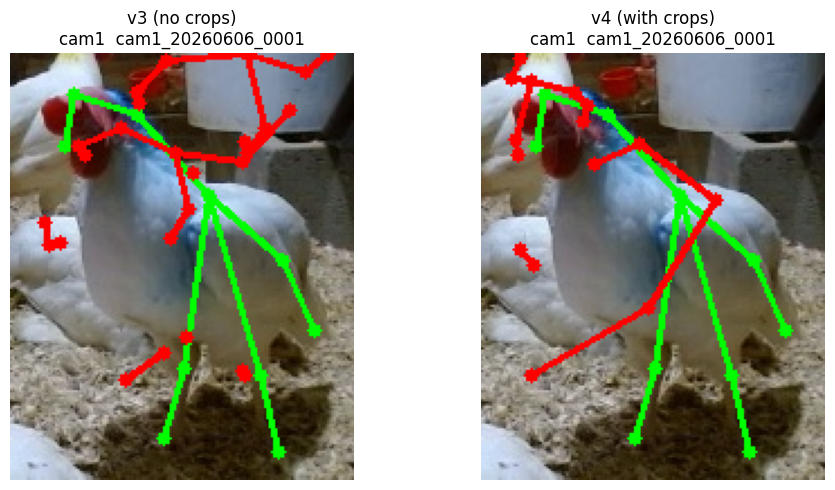

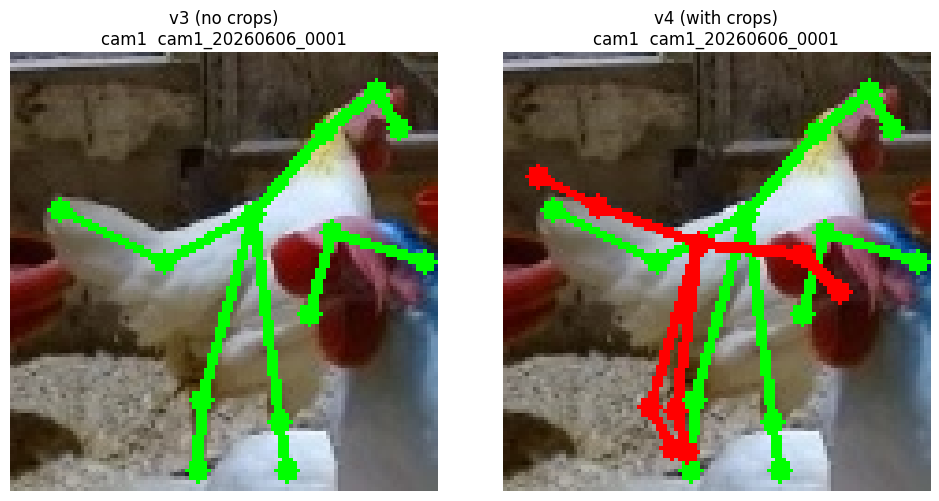

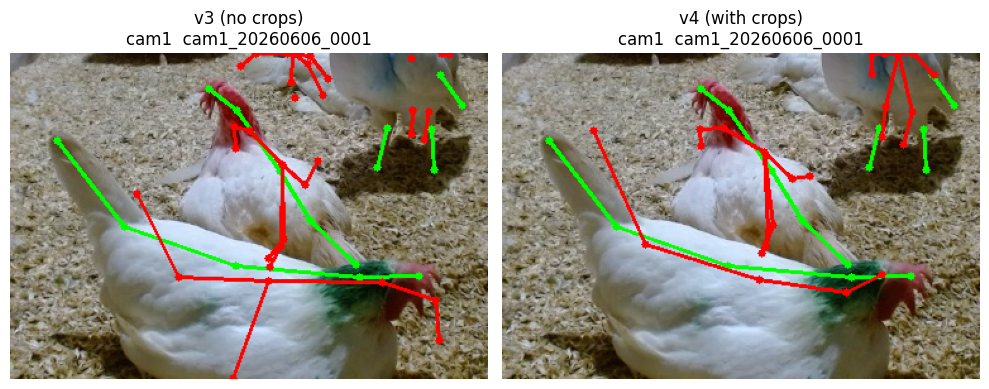

In [5]:
# Side-by-side skeletons per crop: green = ground truth, red = prediction.
import matplotlib.pyplot as plt

def draw(img, insts, color):
    out = img.copy()
    for d in insts:
        k = d["kpts"]
        for a, c in SKELETON:
            if k[a, 2] > 0.25 and k[c, 2] > 0.25:
                cv2.line(out, (int(k[a, 0]), int(k[a, 1])), (int(k[c, 0]), int(k[c, 1])), color, 2)
        for j in range(N_KPTS):
            if k[j, 2] > 0.25:
                cv2.circle(out, (int(k[j, 0]), int(k[j, 1])), 3, color, -1)
    return out

mnames = list(MODELS)
for ip in imgs:
    fig, ax = plt.subplots(1, len(mnames), figsize=(5 * len(mnames), 5))
    ax = np.atleast_1d(ax).ravel()
    for c, m in enumerate(mnames):
        img, gts, preds = preds_cache[(m, ip.name)]
        vis = draw(img, gts, (0, 255, 0))     # GT
        vis = draw(vis, preds, (0, 0, 255))   # prediction
        ax[c].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)); ax[c].axis("off")
        ax[c].set_title(f"{m}\n{cam_of(ip.name)}  {ip.stem[:18]}")
    plt.tight_layout(); plt.show()

## How to read this

- **PCK@0.10 (overall)** is the headline. If `v4` > `v3`, labeling the crops improved crop-pose; if not, the crops did not help (or the val set is too small to tell — only ~12 crops).
- **Per-camera split.** Expect **cam1 (side)** PCK to be higher than **cam0 (top)**. The top crops are frequently motion-blurred, which caps keypoint accuracy regardless of model. If cam0 PCK is much lower, the blur — not the model — is the bottleneck, and a lateral-posture model should be evaluated/used mainly on cam1.

### On the two issues you raised
- **Padding.** These crops use 0.10 padding (from `scripts/build_hen_crops.py`). For the pose model to see the same kind of input in production, the behavior pipeline's eventual crop-for-pose step must use the **same** 0.10 padding. (`crop_hens.ipynb` used 0.15 and `track_pen.py` doesn't crop for pose yet — standardize to one value.)
- **Blur.** Consider filtering low-sharpness crops (variance of the Laplacian below a threshold) out of training, and/or sourcing more **side-view** crops, so the pose model trains on clearer, more relevant postures.

### Caveat
The crop val set is small (~12 images), so treat differences as indicative, not definitive. Grow the labeled crop set (more side-view, sharper frames) for a firmer conclusion.